In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *

In [3]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

df = basic_cleaning(df)

In [4]:
df = create_features(df)

In [5]:
features = [
    "Applicant_Income",
    "Annual_Household_Income",
    "Asset_Value",
    "Existing_EMIs",
    "Employment_Length_Years",
    "CIBIL_Score",
    "Monthly_Expense",
    "Debt_to_Income_Ratio",
    "Occupation",
    "Property_Area",
    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "Loan_Amount"

In [6]:
X, y = select_features(
    df,
    features,
    target
)

In [7]:
num_features, cat_features = get_feature_types(X)

In [8]:
num_features, cat_features = get_feature_types(X)

In [11]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
lr_pipeline = build_pipeline(
    preprocessor,
    LinearRegression()
)

In [14]:
lr_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Applicant_Income','Annual_Household_Income','Asset_Value',..., 'Total_Income','Loan_Income_Ratio','EMI_Income_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be

In [15]:
lr_pred = predict(
    lr_pipeline,
    X_test
)

In [16]:
lr_results = evaluate_regression(
    y_test,
    lr_pred
)
lr_results

,MAE,MSE,RMSE,R2 Score
0,1.961645e+06,6.276033e+12,2.505201e+06,-0.034152


In [17]:
rf_pipeline = build_pipeline(

    preprocessor,

    RandomForestRegressor(
        random_state=42
    )

)

In [18]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [19]:
grid_rf = perform_grid_search(
    rf_pipeline,
    rf_params,
    X_train,
    y_train,
    scoring="r2"
)

In [20]:
rf_best_model = grid_rf.best_estimator_

In [21]:
rf_pred = predict(
    rf_best_model,
    X_test
)

In [22]:
rf_results = evaluate_regression(
    y_test,
    rf_pred
)
rf_results

,MAE,MSE,RMSE,R2 Score
0,231784.092824,2.724564e+11,521973.551318,0.955105


In [23]:
gb_pipeline = build_pipeline(
    preprocessor,
    GradientBoostingRegressor(
        random_state=42
    )
)

In [24]:
gb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Applicant_Income','Annual_Household_Income','Asset_Value',..., 'Total_Income','Loan_Income_Ratio','EMI_Income_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be

In [25]:
gb_pred = predict(
    gb_pipeline,
    X_test
)

In [26]:
gb_results = evaluate_regression(
    y_test,
    gb_pred
)
gb_results

,MAE,MSE,RMSE,R2 Score
0,276893.472195,2.325465e+11,482230.733069,0.961681


In [27]:
comparison = pd.concat(

    [

        lr_results,

        rf_results,

        gb_results

    ],

    keys=[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ]

)

comparison

,,MAE,MSE,RMSE,R2 Score
Linear Regression,0,1.961645e+06,6.276033e+12,2.505201e+06,-0.034152
Random Forest,0,2.317841e+05,2.724564e+11,5.219736e+05,0.955105
Gradient Boosting,0,2.768935e+05,2.325465e+11,4.822307e+05,0.961681


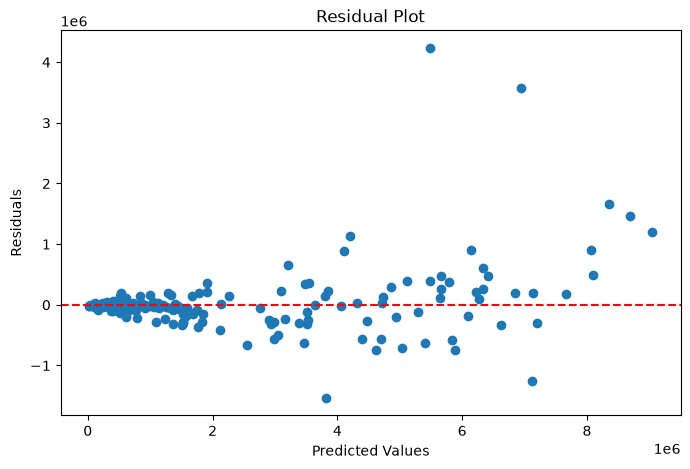

In [28]:
residual_plot(
    y_test,
    rf_pred
)

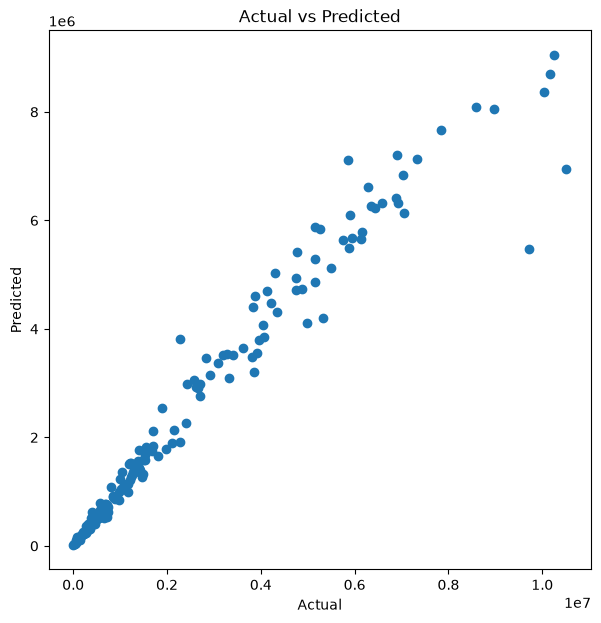

In [29]:
actual_vs_predicted(
    y_test,
    rf_pred
)

In [31]:
best_rf = grid_rf.best_estimator_

In [32]:
joblib.dump(
    best_rf,

    "../models/loan_amount_model.pkl"

)
print("Loan Amount Prediction Model Saved Successfully")

Loan Amount Prediction Model Saved Successfully
